在 MMCA 迭代中：每步计算出 Theta_next，对所有满足 Theta_next < theta_del 且仍为 active 的超边，以概率 r_iso 删除（即将该边标记为 inactive 并把其 Theta 置 0）。

删除有上限：当被删除的超边比例达到 f_max（例如 0.1）后，不再执行任何删除操作（保持现有 active 状态）。

对每个 beta（横轴）做 R 次独立重复（不同随机超图），记录稳态 rho*（MMCA 收敛或达到 max_iter）并计算均值/标准差。

输出 summary CSV，保存图像 rho_vs_beta_theta_del.png（四条曲线：theta_del = 0.0,0.1,0.2,0.3）。

In [7]:
#!/usr/bin/env python3
# mmca_probabilistic_delete_vs_beta_parallel_run.py
"""
运行模拟部分：使用 joblib 并行扫描 beta 和 theta_del 参数，保存结果到CSV
"""

import os
import time
import math
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# -------------------- hypergraph generator --------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------- MMCA with probabilistic deletion --------------------
class MMCAProbDelete:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0].copy()
        self.edge_j = self.hyperedges[:,1].copy()
        self.edge_k = self.hyperedges[:,2].copy()
        # node incidence: list of (edge_idx, pos)
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def run_mmca_with_prob_delete(self,
                                  beta_d, mu, eta, gamma,
                                  theta_del, r_iso, f_max,
                                  init_frac=0.01,
                                  tol=1e-8, max_iter=2000,
                                  rng_seed=None,
                                  verbose=False):
        """
        Run MMCA with probabilistic deletion
        """
        rng = np.random.RandomState(rng_seed) if rng_seed is not None else np.random

        n = self.n; m = self.m
        p = np.full(n, init_frac, dtype=float)
        Theta = np.ones(m, dtype=float)
        active = np.ones(m, dtype=bool)

        rho_hist = []
        iters = 0
        for it in range(max_iter):
            rho_hist.append(p.mean())

            # 计算每个超边中其他节点的感染概率乘积
            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            # 计算每个节点不被感染的概率 Q_i
            Q = np.ones(n, dtype=float)
            for node in range(n):
                prod_val = 1.0
                for (ei,pos) in self.node_edge_pos[node]:
                    if not active[ei]:
                        continue
                    if pos == 0:
                        oth = prod_pos0[ei]
                    elif pos == 1:
                        oth = prod_pos1[ei]
                    else:
                        oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * oth)
                Q[node] = prod_val

            # MMCA update
            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p

            # Theta update
            p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
            Phi = p_i * p_j * p_k
            Theta_next = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
            Theta_next = np.clip(Theta_next, 0.0, 1.0)

            # 概率删除机制
            current_deleted_frac = float((~active).sum()) / float(m)
            # 检查当前删除比例是否达到上限
            if current_deleted_frac < f_max:
                # 找出候选删除的超边：活跃度低于阈值且仍活跃
                cand_idx = np.where((Theta_next < theta_del) & active)[0]
                if cand_idx.size > 0:
                    # 概率r_iso删除：
                    draws = rng.random(cand_idx.size)
                    to_delete_local = cand_idx[draws < r_iso]
                    if to_delete_local.size > 0:
                        # 计算剩余删除配额
                        remaining_budget = int(math.floor(f_max * m)) - int((~active).sum())
                        if remaining_budget <= 0:
                            to_delete = np.array([], dtype=int)
                        else:
                            # 如果候选删除数超过配额，随机选择一部分
                            if to_delete_local.size > remaining_budget:
                                to_delete = rng.choice(to_delete_local, size=remaining_budget, replace=False)
                            else:
                                to_delete = to_delete_local
                        if to_delete.size > 0:
                            active[to_delete] = False
                            Theta_next[to_delete] = 0.0

            # 收敛检查
            dp = np.max(np.abs(p_next - p))
            dTheta = np.max(np.abs(Theta_next - Theta))
            p = p_next
            Theta = Theta_next
            iters = it + 1

            if dp < tol and dTheta < tol:
                break

        rho_final = float(p.mean())
        num_deleted = int((~active).sum())
        f_del = num_deleted / float(m)
        return {
            'rho_final': rho_final,
            'iters': iters,
            'num_deleted': num_deleted, # 删除的超边数量
            'f_del': f_del,   # 删除比例
            'rho_hist': np.array(rho_hist), # 感染密度历史
            'active_mask': active.copy() # 最终活跃状态
        }

# -------------------- 并行任务函数 --------------------
def run_single_prob_delete_simulation(params):
    """
    单个概率删除模拟任务的并行执行函数
    """
    (theta_del, beta, r, n, kappa, mu, eta, gamma, 
     r_iso, f_max, init_frac, tol, max_iter, seed_base, reuse_graph) = params
    
    # 生成随机种子
    gen_seed = None if seed_base is None else (seed_base + r if not reuse_graph else seed_base)
    run_seed = None if seed_base is None else (seed_base + 100000*int(beta*1000) + r)
    
    # 生成超图并运行模拟
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed)
    model = MMCAProbDelete(hyperedges, n)
    res = model.run_mmca_with_prob_delete(
        beta_d=beta, mu=mu, eta=eta, gamma=gamma,
        theta_del=theta_del, r_iso=r_iso, f_max=f_max,
        init_frac=init_frac, tol=tol, max_iter=max_iter,
        rng_seed=run_seed, verbose=False
    )
    
    # 返回结果
    return {
        'theta_del': theta_del,
        'beta': beta,
        'run': r,
        'rho_final': res['rho_final'],
        'f_del': res['f_del'],
        'num_deleted': res['num_deleted'],
        'iters': res['iters']
    }

# -------------------- 并行扫描驱动函数 --------------------
def sweep_beta_prob_delete_parallel(n, kappa,
                                   beta_list, mu, eta, gamma,
                                   theta_del_list, r_iso, f_max,
                                   R=20, init_frac=0.01,
                                   tol=1e-8, max_iter=2000,
                                   reuse_graph=False,
                                   seed_base=12345,
                                   out_dir="out_prob_del_parallel",
                                   verbose=False,
                                   n_jobs=-1):
    """
    并行版本：使用 joblib 并行执行所有模拟
    """
    os.makedirs(out_dir, exist_ok=True)

    # 准备所有参数组合
    print("准备参数组合...")
    param_combinations = []
    for theta_del in theta_del_list:
        for beta in beta_list:
            for r in range(R):
                params = (theta_del, beta, r, n, kappa, mu, eta, gamma, 
                         r_iso, f_max, init_frac, tol, max_iter, seed_base, reuse_graph)
                param_combinations.append(params)
    
    print(f"总共 {len(param_combinations)} 个参数组合")
    print(f"theta_del 值: {theta_del_list}")
    print(f"beta 值: {len(beta_list)} 个点")
    print(f"每个参数组合重复次数: {R}")

    # 使用 joblib 并行执行
    print("开始并行计算...")
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(run_single_prob_delete_simulation)(params) 
        for params in param_combinations
    )
    
    # 收集结果
    print("收集结果...")
    rows = list(results)
    
    # 创建 DataFrame
    df_runs = pd.DataFrame(rows)
    summary = df_runs.groupby(['theta_del', 'beta']).agg(
        mean_rho=('rho_final', 'mean'),
        std_rho=('rho_final', 'std'),
        mean_fdel=('f_del', 'mean'),
        std_fdel=('f_del', 'std'),
        mean_deleted=('num_deleted', 'mean')
    ).reset_index().sort_values(['theta_del', 'beta'])

    # 保存 CSVs
    summary_fn = os.path.join(out_dir, "prob_del_summary.csv")
    runs_fn = os.path.join(out_dir, "prob_del_perrun.csv")
    summary.to_csv(summary_fn, index=False, float_format="%.6f")
    df_runs.to_csv(runs_fn, index=False, float_format="%.6f")
    print(f"保存汇总数据 -> {summary_fn}")
    print(f"保存每次运行数据 -> {runs_fn}")

    return summary, df_runs

# -------------------- Parameters (edit here) --------------------
# Network / model
n = 1500
kappa = 6.0

# Sweep
beta_list = np.linspace(0.20, 0.50, 31)   # beta range [0.10,0.40]
theta_del_list = [0.1, 0.2, 0.3, 0.4]     # four curves requested

# MMCA params
mu = 0.1
eta = 0.6
gamma = 0.02

# deletion mechanism
r_iso = 1      # deletion probability when Theta_next < theta_del
f_max = 0.20     # max fraction of edges allowed to be deleted (10%)

# repeats / convergence
R = 15
init_frac = 0.3
tol = 1e-6
max_iter = 1000
reuse_graph = False   # if True, use same graph for all repeats (not recommended here)
seed_base = 12345
out_dir = "out_prob_del_parallel"
verbose = True
n_jobs = 17  # 使用所有可用的CPU核心，可以改为具体数字

# -------------------- Run when executed --------------------
if __name__ == "__main__":
    t0 = time.time()
    summary_df, runs_df = sweep_beta_prob_delete_parallel(
        n=n, kappa=kappa,
        beta_list=beta_list, mu=mu, eta=eta, gamma=gamma,
        theta_del_list=theta_del_list, r_iso=r_iso, f_max=f_max,
        R=R, init_frac=init_frac,
        tol=tol, max_iter=max_iter,
        reuse_graph=reuse_graph, seed_base=seed_base,
        out_dir=out_dir, verbose=verbose, n_jobs=n_jobs
    )
    print("完成! 耗时: {:.1f}s".format(time.time() - t0))

准备参数组合...
总共 1860 个参数组合
theta_del 值: [0.1, 0.2, 0.3, 0.4]
beta 值: 31 个点
每个参数组合重复次数: 15
开始并行计算...


[Parallel(n_jobs=17)]: Using backend LokyBackend with 17 concurrent workers.
[Parallel(n_jobs=17)]: Done   7 tasks      | elapsed:    3.7s
[Parallel(n_jobs=17)]: Done  16 tasks      | elapsed:    3.9s
[Parallel(n_jobs=17)]: Done  27 tasks      | elapsed:    6.5s
[Parallel(n_jobs=17)]: Done  38 tasks      | elapsed:    8.9s
[Parallel(n_jobs=17)]: Done  51 tasks      | elapsed:    9.1s
[Parallel(n_jobs=17)]: Done  64 tasks      | elapsed:   11.3s
[Parallel(n_jobs=17)]: Done  79 tasks      | elapsed:   13.5s
[Parallel(n_jobs=17)]: Done  94 tasks      | elapsed:   15.5s
[Parallel(n_jobs=17)]: Done 111 tasks      | elapsed:   17.6s
[Parallel(n_jobs=17)]: Done 128 tasks      | elapsed:   19.6s
[Parallel(n_jobs=17)]: Done 147 tasks      | elapsed:   21.7s
[Parallel(n_jobs=17)]: Done 166 tasks      | elapsed:   23.6s
[Parallel(n_jobs=17)]: Done 187 tasks      | elapsed:   25.7s
[Parallel(n_jobs=17)]: Done 208 tasks      | elapsed:   28.5s
[Parallel(n_jobs=17)]: Done 231 tasks      | elapsed:  

收集结果...
保存汇总数据 -> out_prob_del_parallel\prob_del_summary.csv
保存每次运行数据 -> out_prob_del_parallel\prob_del_perrun.csv
完成! 耗时: 196.5s


[Parallel(n_jobs=17)]: Done 1860 out of 1860 | elapsed:  3.3min finished


正在读取数据: out_prob_del_parallel\prob_del_summary.csv
保存图像 -> out_prob_del_parallel\rho_vs_beta_theta_del.png


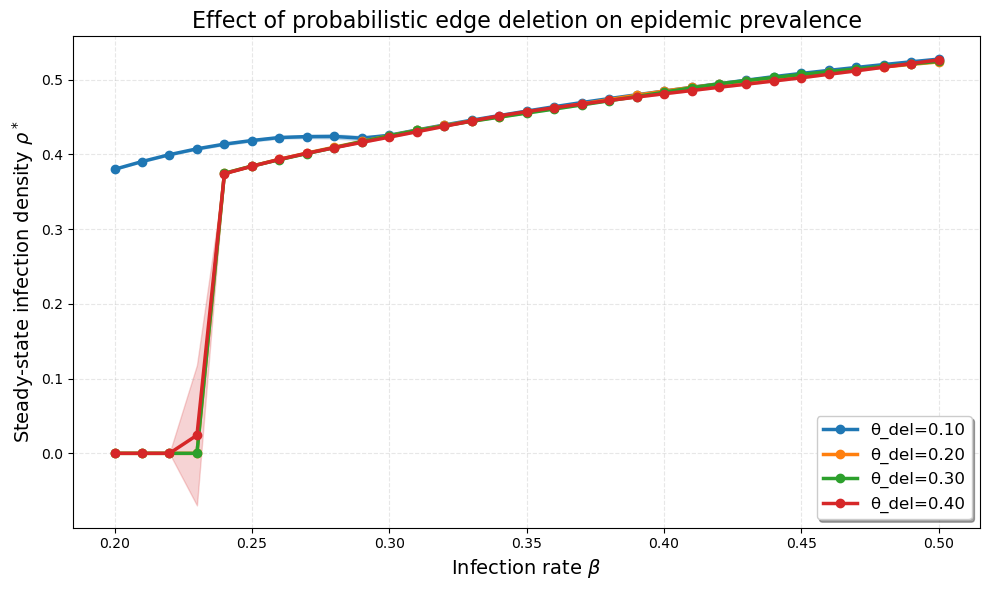

保存图像 -> out_prob_del_parallel\fdel_vs_beta_theta_del.png


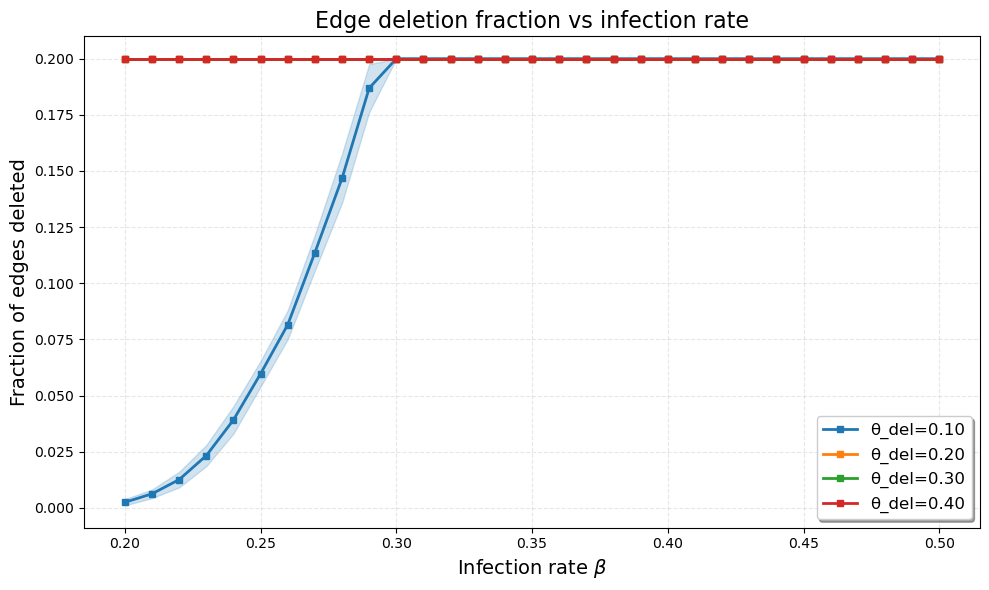


数据统计:
参数范围: beta ∈ [0.20, 0.50]
theta_del 值: [0.1, 0.2, 0.3, 0.4]
平均感染密度范围: [0.0000, 0.5276]
平均删除比例范围: [0.0025, 0.2000]
绘图完成!


In [8]:
#!/usr/bin/env python3
# mmca_probabilistic_delete_vs_beta_parallel_plot.py
"""
绘图部分：从CSV文件读取数据并绘制概率删除效果的图表
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_probabilistic_delete_results(out_dir="out_prob_del_parallel"):
    """
    从CSV文件读取数据并绘制概率删除效果的图表
    """
    # 检查文件是否存在
    summary_fn = os.path.join(out_dir, "prob_del_summary.csv")
    if not os.path.exists(summary_fn):
        print(f"错误: 找不到文件 {summary_fn}")
        return
    
    # 读取汇总数据
    print(f"正在读取数据: {summary_fn}")
    summary = pd.read_csv(summary_fn)
    
    # 绘制 rho vs beta 对于每个 theta_del
    plt.figure(figsize=(10, 6))
    cmap = plt.get_cmap('tab10')
    
    # 获取唯一的 theta_del 值并排序
    theta_del_values = sorted(summary['theta_del'].unique())
    
    for idx, theta_del in enumerate(theta_del_values):
        df_slice = summary[summary['theta_del'] == theta_del]
        beta_vals = df_slice['beta'].to_numpy()
        mean_rho = df_slice['mean_rho'].to_numpy()
        std_rho = df_slice['std_rho'].to_numpy()
        color = cmap(idx)
        
        # 绘制均值曲线和误差带
        plt.plot(beta_vals, mean_rho, '-o', color=color, 
                label=f'θ_del={theta_del:.2f}', linewidth=2.5, markersize=6)
        plt.fill_between(beta_vals, mean_rho - std_rho, mean_rho + std_rho, 
                        color=color, alpha=0.2)
    
    # 美化图表
    plt.xlabel(r'Infection rate $\beta$', fontsize=14)
    plt.ylabel(r'Steady-state infection density $\rho^*$', fontsize=14)
    plt.title('Effect of probabilistic edge deletion on epidemic prevalence', fontsize=16)
    plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # 保存图像
    fig_fn = os.path.join(out_dir, "rho_vs_beta_theta_del.png")
    plt.savefig(fig_fn, dpi=300, bbox_inches='tight')
    print(f"保存图像 -> {fig_fn}")
    plt.show()
    
    # 可选：绘制删除比例 vs beta
    plt.figure(figsize=(10, 6))
    for idx, theta_del in enumerate(theta_del_values):
        df_slice = summary[summary['theta_del'] == theta_del]
        beta_vals = df_slice['beta'].to_numpy()
        mean_fdel = df_slice['mean_fdel'].to_numpy()
        std_fdel = df_slice['std_fdel'].to_numpy()
        color = cmap(idx)
        
        plt.plot(beta_vals, mean_fdel, '-s', color=color, 
                label=f'θ_del={theta_del:.2f}', linewidth=2, markersize=5)
        plt.fill_between(beta_vals, mean_fdel - std_fdel, mean_fdel + std_fdel, 
                        color=color, alpha=0.2)
    
    plt.xlabel(r'Infection rate $\beta$', fontsize=14)
    plt.ylabel('Fraction of edges deleted', fontsize=14)
    plt.title('Edge deletion fraction vs infection rate', fontsize=16)
    plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    fig_fn2 = os.path.join(out_dir, "fdel_vs_beta_theta_del.png")
    plt.savefig(fig_fn2, dpi=300, bbox_inches='tight')
    print(f"保存图像 -> {fig_fn2}")
    plt.show()
    
    # 显示数据统计信息
    print("\n数据统计:")
    print(f"参数范围: beta ∈ [{summary['beta'].min():.2f}, {summary['beta'].max():.2f}]")
    print(f"theta_del 值: {theta_del_values}")
    print(f"平均感染密度范围: [{summary['mean_rho'].min():.4f}, {summary['mean_rho'].max():.4f}]")
    print(f"平均删除比例范围: [{summary['mean_fdel'].min():.4f}, {summary['mean_fdel'].max():.4f}]")

# -------------------- 主程序 --------------------
if __name__ == "__main__":
    # 设置输出目录（与运行脚本中的目录一致）
    out_dir = "out_prob_del_parallel"
    
    # 绘制结果
    plot_probabilistic_delete_results(out_dir)
    
    print("绘图完成!")